In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add
# 1. define state
class OverallState(TypedDict):
    logs: Annotated[list[str], add]
    cur_id: str
# 2. define node

def node_1(state: OverallState) -> OverallState:
    pre_id = state["cur_id"]
    return {
        "logs": ["node_1 executed"],
        "cur_id": pre_id + ", node_2"
    }

def node_2(state: OverallState) -> OverallState:
    pre_id = state["cur_id"]
    return {
        "logs": ["node_2 executed"],
        "cur_id": pre_id + ", node_2"
    }

# 3 define edge
# 3.1 create graph, get creator
builder = StateGraph(state_schema=OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)
#4 Get the graph    
graph = builder.compile()

#5 Run the graph
result = graph.invoke({"logs": [], "cur_id": "start"})
print(result)

{'logs': ['node_1 executed', 'node_2 executed'], 'cur_id': 'start, node_2, node_2'}


In [2]:
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc
```

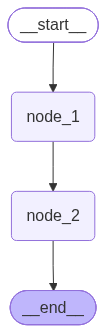

In [3]:
from IPython.display import display, Image
png_bytes = graph.get_graph().draw_mermaid_png()
png_image = Image(png_bytes)
display(png_image)

In [4]:
png_bytes = graph.get_graph().draw_mermaid_png()
png_filename = "first demo graph.png"
with open(png_filename, "wb") as f:
    f.write(png_bytes)

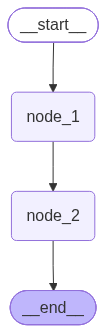

: 

In [ ]:
from IPython.display import display, Image
display(graph)